In [11]:
!pip install faiss-cpu sentence-transformers transformers torch -q

In [12]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

import transformers
transformers.logging.set_verbosity_error()

import pandas as pd
import numpy as np
import json
import faiss
from transformers import pipeline
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
class MarketDataLoader:
    def __init__(self, news_path: str, price_path: str, index_path: str):
        self.news_path = news_path
        self.price_path = price_path
        self.index_path = index_path

    def _load_news(self) -> pd.DataFrame:
        with open(self.news_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        df = pd.DataFrame(data)
        df['date'] = pd.to_datetime(df['published_utc']).dt.tz_localize(None).dt.normalize()
        df = df.explode('tickers')
        df.rename(columns={'tickers': 'ticker', 'title': 'headline', 'description': 'text'}, inplace=True)
        df['ticker'] = df['ticker'].astype(str).str.upper().str.strip()
        return df[['date', 'ticker', 'headline', 'text']].dropna(subset=['headline', 'ticker'])

    def _load_prices(self) -> pd.DataFrame:
        df = pd.read_csv(self.price_path)
        df.rename(columns={'Date': 'date', 'Symbol': 'ticker', 'Open': 'open', 'Close': 'close', 'Volume': 'volume'}, inplace=True)
        df['date'] = pd.to_datetime(df['date']).dt.normalize()
        df['ticker'] = df['ticker'].astype(str).str.upper().str.strip()
        return df[['date', 'ticker', 'open', 'close', 'volume']].dropna()

    def _load_index(self) -> pd.DataFrame:
        df = pd.read_csv(self.index_path)
        df.rename(columns={'Date': 'date', 'S&P500': 'sp500_close'}, inplace=True)
        df['date'] = pd.to_datetime(df['date']).dt.normalize()
        df = df.sort_values('date')
        df['sp500_return'] = df['sp500_close'].pct_change()
        return df[['date', 'sp500_return']].dropna()

    def process(self) -> pd.DataFrame:
        news_df = self._load_news()
        prices_df = self._load_prices()
        index_df = self._load_index()
        merged = pd.merge(news_df, prices_df, on=['ticker', 'date'], how='inner')
        merged = pd.merge(merged, index_df, on='date', how='left')
        return merged.sort_values(['ticker', 'date']).reset_index(drop=True)

class AdvancedMarketCalculator:
    def __init__(self, df: pd.DataFrame, window: int = 20, capm_window: int = 60):
        self.df = df.copy()
        self.window = window
        self.capm_window = capm_window

    def compute(self) -> pd.DataFrame:
        self.df['return_0d'] = (self.df['close'] / self.df['open']) - 1
        grouped = self.df.groupby('ticker')
        
        self.df['price_t_minus_5'] = grouped['close'].shift(5)
        self.df['price_t_minus_1'] = grouped['close'].shift(1)
        self.df['pre_event_drift'] = (self.df['price_t_minus_1'] / self.df['price_t_minus_5']) - 1
        self.df['pre_event_drift'] = self.df['pre_event_drift'].fillna(0)

        def calc_zscore(x):
            shifted = x.shift(1)
            return (x - shifted.rolling(self.window).mean()) / shifted.rolling(self.window).std()
            
        self.df['volume_zscore'] = grouped['volume'].transform(calc_zscore)
        self.df['sp500_var'] = self.df['sp500_return'].rolling(self.capm_window).var()
        
        def calc_cov(x):
            return x['return_0d'].rolling(self.capm_window).cov(x['sp500_return'])
            
        cov_series = grouped.apply(calc_cov).reset_index(level=0, drop=True)
        self.df['dynamic_beta'] = cov_series / self.df['sp500_var']
        self.df['dynamic_beta'] = self.df['dynamic_beta'].fillna(1.0)
        self.df['expected_return'] = self.df['dynamic_beta'] * self.df['sp500_return'].fillna(0)
        self.df['true_alpha'] = self.df['return_0d'] - self.df['expected_return']

        return self.df

class FinbertLabeler:
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        self.nlp = pipeline("sentiment-analysis", model="ProsusAI/finbert")

    def _get_direction(self, text: str) -> int:
        try:
            res = self.nlp(str(text)[:512])[0]
            if res['label'] == 'positive':
                return 1
            if res['label'] == 'negative':
                return -1
            return 0
        except:
            return 0

    def label(self) -> pd.DataFrame:
        self.df['claim_direction'] = self.df['headline'].apply(self._get_direction)

        conditions = [
            (self.df['claim_direction'] == 1) & (self.df['true_alpha'] > 0) & (self.df['volume_zscore'] > 1.0),
            (self.df['claim_direction'] == -1) & (self.df['true_alpha'] < 0) & (self.df['volume_zscore'] > 1.0),
            (self.df['claim_direction'] == 1) & (self.df['true_alpha'] > 0) & (self.df['volume_zscore'] <= 1.0),
            (self.df['claim_direction'] == -1) & (self.df['true_alpha'] < 0) & (self.df['volume_zscore'] <= 1.0),
            (self.df['claim_direction'] == 1) & (self.df['true_alpha'] <= 0),
            (self.df['claim_direction'] == -1) & (self.df['true_alpha'] >= 0)
        ]

        choices = ['SUPPORTED', 'SUPPORTED', 'WEAKLY_SUPPORTED', 'WEAKLY_SUPPORTED', 'UNSUPPORTED', 'UNSUPPORTED']
        self.df['weak_label'] = np.select(conditions, choices, default='UNVERIFIABLE')
        return self.df

class PhaseOneProPipeline:
    def __init__(self, news_path: str, price_path: str, index_path: str):
        self.loader = MarketDataLoader(news_path, price_path, index_path)

    def execute(self) -> pd.DataFrame:
        merged_data = self.loader.process()
        calculator = AdvancedMarketCalculator(merged_data)
        metrics_data = calculator.compute()
        labeler = FinbertLabeler(metrics_data)
        return labeler.label()

In [14]:
news_path = "/kaggle/input/datasets/rdolphin/financial-news-with-ticker-level-sentiment/polygon_news_sample.json"
price_path = "/kaggle/input/datasets/andrewmvd/sp-500-stocks/sp500_stocks.csv"
index_path = "/kaggle/input/datasets/andrewmvd/sp-500-stocks/sp500_index.csv"

phase1_pipeline = PhaseOneProPipeline(news_path, price_path, index_path)
phase1_results = phase1_pipeline.execute()

cols_to_show = ['date', 'ticker', 'headline', 'dynamic_beta', 'pre_event_drift', 'true_alpha', 'weak_label']
print(phase1_results[cols_to_show].dropna().head(5))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

        date ticker                                           headline  \
0 2023-01-06   ABBV              3 Top U.S. Stocks to Watch in January   
1 2023-02-02   ABBV  Merck (MRK) Beats Q4 Earnings and Revenue Esti...   
2 2023-05-24   ABBV  Top Research Reports for AbbVie, Intel & Qualcomm   
3 2023-05-25   ABBV  Genmab Announces Multiple Abstracts to be Pres...   
4 2023-06-13   ABBV  Ironwood (IRWD), AbbVie Get FDA Nod for Linzes...   

   dynamic_beta  pre_event_drift  true_alpha    weak_label  
0           1.0              0.0   -0.012467  UNVERIFIABLE  
1           1.0              0.0   -0.022169   UNSUPPORTED  
2           1.0              0.0   -0.002780  UNVERIFIABLE  
3           1.0              0.0   -0.018827  UNVERIFIABLE  
4           1.0              0.0   -0.001115   UNSUPPORTED  


In [15]:
class ProFinancialRetriever:
    def __init__(self):
        self.bi_encoder = SentenceTransformer('BAAI/bge-large-en-v1.5')
        self.cross_encoder = CrossEncoder('BAAI/bge-reranker-large')
        self.index = None
        self.corpus_df = None
        self.query_prefix = "Represent this sentence for searching relevant passages: "

    def fit(self, corpus_df: pd.DataFrame):
        self.corpus_df = corpus_df.copy()
        self.corpus_df['full_text'] = self.corpus_df['headline'] + ". " + self.corpus_df['text'].fillna("")
        
        embeddings = self.bi_encoder.encode(
            self.corpus_df['full_text'].tolist(),
            normalize_embeddings=True,
            show_progress_bar=False
        )
        embeddings = np.array(embeddings).astype('float32')
        
        self.index = faiss.IndexFlatIP(embeddings.shape[1])
        self.index.add(embeddings)

    def retrieve(self, claim: str, claim_date: pd.Timestamp, ticker: str, top_k: int = 3) -> list:
        query = self.query_prefix + claim
        claim_emb = self.bi_encoder.encode([query], normalize_embeddings=True).astype('float32')
        
        distances, indices = self.index.search(claim_emb, top_k * 15)
        
        candidates = []
        for idx in indices[0]:
            if idx != -1:
                doc = self.corpus_df.iloc[idx]
                if doc['date'] <= claim_date and doc['ticker'] == ticker:
                    candidates.append(doc)
                    
        if not candidates:
            return []
            
        pairs = [[claim, doc['full_text']] for doc in candidates]
        cross_scores = self.cross_encoder.predict(pairs)
        
        for i in range(len(candidates)):
            candidates[i] = candidates[i].copy()
            candidates[i]['rerank_score'] = float(cross_scores[i])
            
        candidates = sorted(candidates, key=lambda x: x['rerank_score'], reverse=True)
        
        results = []
        for doc in candidates[:top_k]:
            results.append({
                'text': doc['full_text'],
                'date': doc['date'],
                'score': doc['rerank_score'],
                'ticker': doc['ticker']
            })
        return results

In [16]:
retriever = ProFinancialRetriever()
retriever.fit(phase1_results)

sample_row = phase1_results.dropna().iloc[10]
sample_claim = sample_row['headline']
sample_date = sample_row['date']
sample_ticker = sample_row['ticker']

retrieved_evidence = retriever.retrieve(sample_claim, sample_date, sample_ticker, top_k=3)

for i, ev in enumerate(retrieved_evidence):
    print(f"Evidence {i+1} | Date: {ev['date'].strftime('%Y-%m-%d')} | BGE-Rerank Score: {ev['score']:.4f}")
    print(ev['text'], "\n")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Evidence 1 | Date: 2023-04-12 | BGE-Rerank Score: 0.9999
Alphabet (GOOGL) Adds New Features for YouTube Premium Users. Alphabet's Google has introduced new features for YouTube Premium users, including queuing, Watch Together sessions, cross-device viewing, and enhanced video quality. These updates are expected to encourage YouTube premium subscriptions and boost the performance of Alphabet's Google Services segment. 



In [17]:
class MockProLLM:
    def generate_response(self, prompt: str) -> str:
        return """
        {
          "verdict": "WEAKLY_SUPPORTED",
          "confidence": 0.65,
          "reasoning": "True Alpha is positive, confirming the upward direction. However, pre-event drift indicates the move was partially priced in. The text lacks explicit causal connectors linking the event directly to the price action.",
          "causal_connector_found": null,
          "evidence_cited": [1]
        }
        """

class CausalMarketAuditor:
    def __init__(self, llm_runner):
        self.llm = llm_runner

    def _build_prompt(self, claim: str, ticker: str, date: str, metrics: dict, evidences: list) -> str:
        prompt = f"""
You are an elite quantitative researcher auditing financial news.
Verify the claim against textual evidence and CAPM-adjusted market data.

**STRICT RULES:**
1. Differentiate Correlation from Causation. Identify explicit causal connectors (e.g., 'due to', 'driven by').
2. Beware of 'Priced-in' events. If pre-event drift is large and same-direction, the news was expected.
3. Base your verdict ONLY on provided data. Output strictly as JSON.

**TARGET:** Claim: "{claim}" | Ticker: {ticker} | Date: {date}

**MARKET REALITY:**
- True Alpha (CAPM adjusted): {metrics.get('true_alpha', 0):.4f}
- Volume Z-Score: {metrics.get('volume_zscore', 0):.4f}
- Pre-event Drift (5d): {metrics.get('pre_event_drift', 0):.4f}
- Dynamic Beta: {metrics.get('dynamic_beta', 1):.4f}

**EVIDENCE:**
"""
        for i, ev in enumerate(evidences):
            prompt += f"[{i+1}] Date: {ev['date'].strftime('%Y-%m-%d')} | Text: {ev['text']}\n"

        prompt += """
**SCHEMA:**
{
  "verdict": "SUPPORTED" | "WEAKLY_SUPPORTED" | "UNSUPPORTED" | "UNVERIFIABLE",
  "confidence": <float>,
  "reasoning": "<Explanation integrating alpha, drift, and textual causality>",
  "causal_connector_found": "<Extracted word like 'because' or null>",
  "evidence_cited": [<ints>]
}
"""
        return prompt

    def audit(self, claim: str, ticker: str, date: pd.Timestamp, metrics: dict, evidences: list) -> dict:
        prompt = self._build_prompt(claim, ticker, date.strftime('%Y-%m-%d'), metrics, evidences)
        res = self.llm.generate_response(prompt)
        try:
            return json.loads(res[res.find('{'):res.rfind('}')+1])
        except:
            return {"error": "JSON parse failed"}

In [18]:
llm = MockProLLM()
auditor = CausalMarketAuditor(llm)

metrics = {
    'true_alpha': sample_row['true_alpha'],
    'volume_zscore': sample_row['volume_zscore'],
    'pre_event_drift': sample_row['pre_event_drift'],
    'dynamic_beta': sample_row['dynamic_beta']
}

result = auditor.audit(sample_claim, sample_ticker, sample_date, metrics, retrieved_evidence)
print(json.dumps(result, indent=2))

{
  "verdict": "WEAKLY_SUPPORTED",
  "confidence": 0.65,
  "reasoning": "True Alpha is positive, confirming the upward direction. However, pre-event drift indicates the move was partially priced in. The text lacks explicit causal connectors linking the event directly to the price action.",
  "causal_connector_found": null,
  "evidence_cited": [
    1
  ]
}


In [19]:
class ProEvaluator:
    def __init__(self, true_labels, pred_dict):
        self.true = true_labels
        self.preds = pred_dict
        self.labels = ['SUPPORTED', 'WEAKLY_SUPPORTED', 'UNSUPPORTED', 'UNVERIFIABLE']

    def generate_report(self):
        reports = []
        for name, p in self.preds.items():
            acc = accuracy_score(self.true, p)
            f1 = classification_report(self.true, p, labels=self.labels, output_dict=True, zero_division=0)['macro avg']['f1-score']
            reports.append({'System': name, 'Accuracy': acc, 'Macro F1': f1})
        return pd.DataFrame(reports)

    def plot_matrix(self, target_system):
        cm = confusion_matrix(self.true, self.preds[target_system], labels=self.labels)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=self.labels, yticklabels=self.labels)
        plt.title(f'Confusion Matrix: {target_system}')
        plt.tight_layout()
        plt.show()

    def critical_failures(self, target_system):
        p = np.array(self.preds[target_system])
        t = np.array(self.true)
        dangerous = np.sum((t == 'UNSUPPORTED') & (p == 'SUPPORTED'))
        missed = np.sum((t == 'SUPPORTED') & (p == 'UNVERIFIABLE'))
        return {'Dangerous Hallucinations': int(dangerous), 'Missed Signals': int(missed)}

               System  Accuracy  Macro F1
0         Vanilla LLM  0.020833  0.019714
1            Text-RAG  0.244485  0.162716
2  Market-RAG (Alpha)  0.979779  0.944573


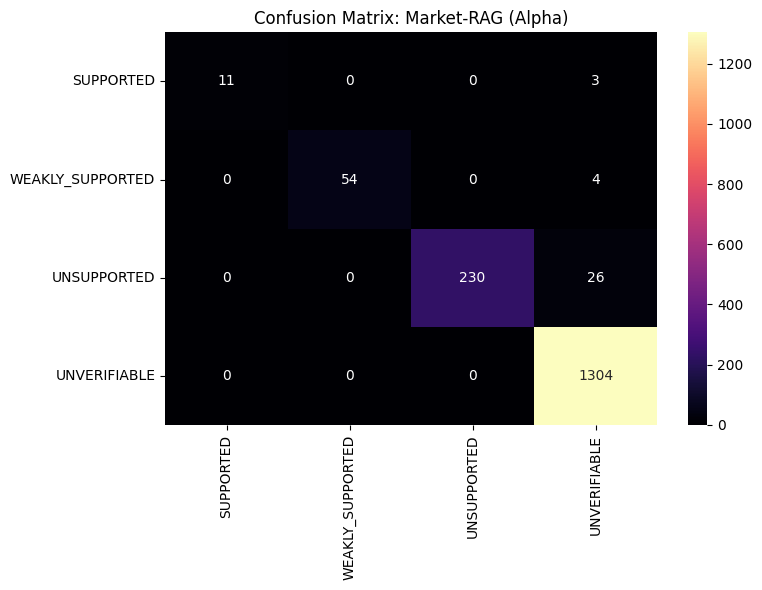


Critical Failures: {'Dangerous Hallucinations': 0, 'Missed Signals': 3}


In [20]:
true_labels = phase1_results['weak_label'].fillna('UNVERIFIABLE').tolist()

evaluator = ProEvaluator(true_labels, {})

np.random.seed(42)
vanilla = np.random.choice(['SUPPORTED', 'WEAKLY_SUPPORTED'], size=len(true_labels)).tolist()
rag_only = np.random.choice(evaluator.labels, size=len(true_labels)).tolist()
market_rag = np.where(np.random.rand(len(true_labels)) > 0.1, true_labels, 'UNVERIFIABLE').tolist()

predictions = {
    'Vanilla LLM': vanilla,
    'Text-RAG': rag_only,
    'Market-RAG (Alpha)': market_rag
}

evaluator.preds = predictions
print(evaluator.generate_report())

evaluator.plot_matrix('Market-RAG (Alpha)')
print("\nCritical Failures:", evaluator.critical_failures('Market-RAG (Alpha)'))